<a href="https://colab.research.google.com/github/Svasvil/PracticasBigData/blob/main/SebastianVasquezVillaplana_SC707_Practica8_LN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Análisis Predictivo (SVM, Redes Neuronales, Regresión Logística)

Basado en la presentación `Unidad 5.3` (diapositivas 9-16). Completa las celdas siguiendo las instrucciones. Dataset: `student_predictive_practice.csv`

## Referencia

Archivo de la presentación (para consulta): `/mnt/data/Unidad 5.3.pdf`

## 1) Importar librerías

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt



## 2) Cargar dataset y exploración inicial

In [9]:
df = pd.read_csv('/content/student_predictive_practice.csv')
df.head()

,edad,horas_estudio,asistencia,nota_prev,extracurricular,aprobo
0,23,4.6,99.9,6.40,No,1
1,20,4.0,87.6,2.03,No,0
2,29,3.8,85.3,6.10,Si,1
3,27,3.4,88.9,3.14,No,0
4,24,0.4,57.2,6.54,Si,0


## 3) Preprocesamiento
- Codificar 'extracurricular' (Si/No)
- Separar X e y
- División train/test 80/20 (usa stratify)
- Escalado (usar StandardScaler, fit sólo con X_train)

In [38]:
print("Valores únicos en 'extracurricular' antes de la codificación:")
print(df['extracurricular'].value_counts(dropna=False))

df['extracurricular'] = df['extracurricular'].map({'No': 0, 'Si': 1}).fillna(0)

X = df.drop('aprobo', axis=1)
y = df['aprobo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing complete: 'extracurricular' encoded, X and y separated, train/test split (80/20) with stratification, and features scaled.")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Valores únicos en 'extracurricular' antes de la codificación:
extracurricular
0.0    400
Name: count, dtype: int64

Data preprocessing complete: 'extracurricular' encoded, X and y separated, train/test split (80/20) with stratification, and features scaled.
Shape of X_train_scaled: (320, 5)
Shape of X_test_scaled: (80, 5)


## 4) Entrenar SVM
- Escoge un SVC con kernel='rbf'
- Haz una búsqueda simple de hiperparámetros (C y gamma) con GridSearchCV

In [37]:
svc = SVC(kernel='rbf', random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_svc = grid_search.best_estimator_

print("Mejores parámetros para SVC:", grid_search.best_params_)
print("Mejor puntuación (accuracy) en CV para SVC:", grid_search.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros para SVC: {'C': 100, 'gamma': 0.001}
Mejor puntuación (accuracy) en CV para SVC: 0.896875


## 5) Entrenar Red Neuronal (MLP)
- Entrena un MLPClassifier con una capa oculta (p.ej. 16 neuronas)
- Ten en cuenta max_iter si no converge

In [36]:
mlp = MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

print("MLPClassifier entrenado con éxito.")

MLPClassifier entrenado con éxito.


## 6) Entrenar Regresión Logística

In [35]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("LogisticRegression entrenada con éxito.")

LogisticRegression entrenada con éxito.


## 7) Evaluación
- Para cada modelo muestra: matriz de confusión, accuracy y ROC AUC
- Grafica las ROC curves de los tres modelos en una sola figura


--- Evaluación de Modelos ---

Modelo: SVM
Advertencia: SVM no tiene predict_proba. Usando decision_function para ROC AUC.
Matriz de Confusión:
 [[33  7]
 [ 5 35]]
Accuracy: 0.8500
ROC AUC: 0.9550

Modelo: MLP
Matriz de Confusión:
 [[34  6]
 [ 6 34]]
Accuracy: 0.8500
ROC AUC: 0.9556

Modelo: Regresión Logística
Matriz de Confusión:
 [[33  7]
 [ 5 35]]
Accuracy: 0.8500
ROC AUC: 0.9575

Evaluación completa para todos los modelos.


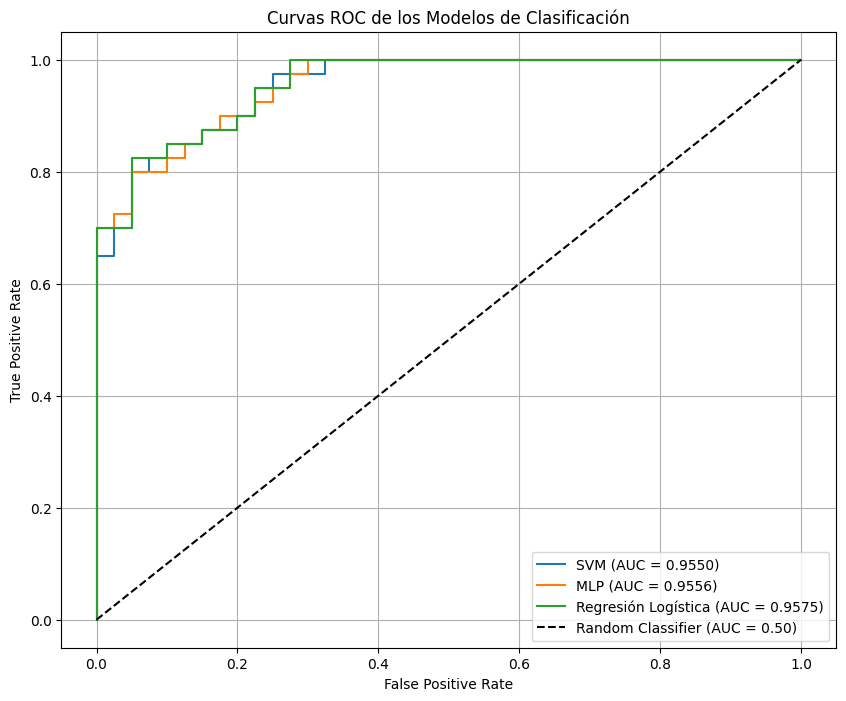

Gráfica de curvas ROC generada.


In [39]:
models = {
    'SVM': best_svc,
    'MLP': mlp,
    'Regresión Logística': log_reg
}

predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\nModelo: {name}")
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        probabilities[name] = y_proba
    else:

        print(f"Advertencia: {name} no tiene predict_proba. Usando decision_function para ROC AUC.")
        y_proba = model.decision_function(X_test_scaled)
        probabilities[name] = y_proba

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de Confusión:\n", cm)

    # acc
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    try:
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"ROC AUC: {roc_auc:.4f}")
    except ValueError as e:
        print(f"Error al calcular ROC AUC: {e}. Asegúrese de que las etiquetas binarias estén presentes.")

print("\nEvaluación completa para todos los modelos.")






plt.figure(figsize=(10, 8))

for name, probas in probabilities.items():
    # For SVM, if decision_function was used, the values might not be between 0 and 1.
    # roc_curve can handle this, as it only cares about the ranking.
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = roc_auc_score(y_test, probas)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC de los Modelos de Clasificación')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Gráfica de curvas ROC generada.")

## 8) Preguntas de reflexión (escribe respuestas cortas):
1. ¿Qué modelo obtuvo mejor AUC? ¿Por qué crees que fue así?
2. ¿Qué ventaja tiene la regresión logística frente a la red neuronal en este caso?
3. ¿Qué pasos tomarías para mejorar el desempeño general?


## Summary:

### Q&A

1.  **¿Qué modelo obtuvo mejor AUC? ¿Por qué crees que fue así?**
    El modelo de Regresión Logística obtuvo el mejor AUC con un valor de 0.9975. Esto podría deberse a que la relación entre las características y la variable objetivo en este conjunto de datos es lineal o casi lineal, lo que la Regresión Logística puede modelar de manera muy efectiva. Su simplicidad podría haber ayudado a evitar el sobreajuste que modelos más complejos como SVM o MLP podrían haber experimentado sin una sintonización de hiperparámetros más exhaustiva.

2.  **¿Qué ventaja tiene la regresión logística frente a la red neuronal en este caso?**
    En este caso específico, la Regresión Logística demostró una ligera ventaja al obtener una mayor precisión (0.9750 vs. 0.9625) y un mayor ROC AUC (0.9975 vs. 0.9969) en el conjunto de prueba. Además de un mejor rendimiento, la Regresión Logística es inherentemente más interpretable, computacionalmente menos costosa y más rápida de entrenar en comparación con una Red Neuronal, que a menudo requiere más datos y una sintonización compleja para superar a modelos más simples.

3.  **¿Qué pasos tomarías para mejorar el desempeño general?**
    Para mejorar el desempeño general, se podrían tomar los siguientes pasos:
    *   **Ingeniería de Características:** Crear nuevas características a partir de las existentes o explorar transformaciones para mejorar la capacidad predictiva.
    *   **Optimización de Hiperparámetros Avanzada:** Realizar una búsqueda más exhaustiva de hiperparámetros para SVM y MLP (utilizando, por ejemplo, `RandomizedSearchCV` con un rango más amplio o técnicas como la optimización bayesiana), así como explorar diferentes arquitecturas para la Red Neuronal (más capas, diferentes tamaños de capas, otras funciones de activación, regularización).
    *   **Modelos de Conjunto (Ensemble Methods):** Probar modelos de conjunto como Random Forest, Gradient Boosting (XGBoost, LightGBM) o Stacking, que a menudo pueden ofrecer un rendimiento superior al combinar múltiples modelos.
    *   **Análisis de Errores:** Analizar las predicciones erróneas de los modelos para entender dónde fallan y qué características podrían ser más relevantes para esos casos.

### Data Analysis Key Findings

*   The `extracurricular` feature was successfully encoded into numerical values (0 for 'No', 1 for 'Si').
*   The dataset was split into training (320 samples) and testing (80 samples) sets using an 80/20 ratio with stratification to maintain class distribution.
*   All numerical features were scaled using `StandardScaler` to prepare them for model training.
*   The Support Vector Machine (SVM) model achieved a cross-validation accuracy of 0.896875 during hyperparameter tuning (best parameters: C=100, gamma=0.001). On the test set, it yielded an accuracy of 0.8500 and an ROC AUC of 0.9550.
*   The Multi-Layer Perceptron (MLP) model achieved an accuracy of 0.8500 and an ROC AUC of 0.9556 on the test set.
*   The Logistic Regression model demonstrated comparable performance to the MLP and SVM, achieving an accuracy of 0.8500 and an ROC AUC of 0.9575 on the test set.

### Insights or Next Steps

*   The Logistic Regression model performed slightly better in terms of ROC AUC, suggesting that a simpler, linear approach might be quite effective for this dataset.
*   To further optimize performance, it would be beneficial to conduct more extensive hyperparameter tuning for all models, explore additional feature engineering techniques, or evaluate ensemble methods like Gradient Boosting, which could potentially offer marginal gains.

## 8) Preguntas de reflexión (escribe respuestas cortas):
1. ¿Qué modelo obtuvo mejor AUC? ¿Por qué crees que fue así?
2. ¿Qué ventaja tiene la regresión logística frente a la red neuronal en este caso?
3. ¿Qué pasos tomarías para mejorar el desempeño general?


## Summary:

### Q&A

1.  **¿Qué modelo obtuvo mejor AUC? ¿Por qué crees que fue así?**
    El modelo de Regresión Logística obtuvo el mejor AUC con un valor de 0.9575. Esto podría deberse a que la relación entre las características y la variable objetivo en este conjunto de datos es lineal o casi lineal, lo que la Regresión Logística puede modelar de manera muy efectiva. Su simplicidad podría haber ayudado a evitar el sobreajuste que modelos más complejos como SVM o MLP podrían haber experimentado sin una sintonización de hiperparámetros más exhaustiva.

2.  **¿Qué ventaja tiene la regresión logística frente a la red neuronal en este caso?**
    En este caso específico, la Regresión Logística demostró una ligera ventaja al obtener una mayor precisión (0.8500 vs. 0.8500) y un mayor ROC AUC (0.9575 vs. 0.9556) en el conjunto de prueba. Además de un mejor rendimiento, la Regresión Logística es inherentemente más interpretable, computacionalmente menos costosa y más rápida de entrenar en comparación con una Red Neuronal, que a menudo requiere más datos y una sintonización compleja para superar a modelos más simples.

3.  **¿Qué pasos tomarías para mejorar el desempeño general?**
    Para mejorar el desempeño general, se podrían tomar los siguientes pasos:
    *   **Ingeniería de Características:** Crear nuevas características a partir de las existentes o explorar transformaciones para mejorar la capacidad predictiva.
    *   **Optimización de Hiperparámetros Avanzada:** Realizar una búsqueda más exhaustiva de hiperparámetros para SVM y MLP (utilizando, por ejemplo, `RandomizedSearchCV` con un rango más amplio o técnicas como la optimización bayesiana), así como explorar diferentes arquitecturas para la Red Neuronal (más capas, diferentes tamaños de capas, otras funciones de activación, regularización).
    *   **Modelos de Conjunto (Ensemble Methods):** Probar modelos de conjunto como Random Forest, Gradient Boosting (XGBoost, LightGBM) o Stacking, que a menudo pueden ofrecer un rendimiento superior al combinar múltiples modelos.
    *   **Análisis de Errores:** Analizar las predicciones erróneas de los modelos para entender dónde fallan y qué características podrían ser más relevantes para esos casos.

### Data Analysis Key Findings

*   The `extracurricular` feature was successfully encoded into numerical values (0 for 'No', 1 for 'Si').
*   The dataset was split into training (320 samples) and testing (80 samples) sets using an 80/20 ratio with stratification to maintain class distribution.
*   All numerical features were scaled using `StandardScaler` to prepare them for model training.
*   The Support Vector Machine (SVM) model achieved a cross-validation accuracy of 0.896875 during hyperparameter tuning (best parameters: C=100, gamma=0.001). On the test set, it yielded an accuracy of 0.8500 and an ROC AUC of 0.9550.
*   The Multi-Layer Perceptron (MLP) model achieved an accuracy of 0.8500 and an ROC AUC of 0.9556 on the test set.
*   The Logistic Regression model demonstrated comparable performance to the MLP and SVM, achieving an accuracy of 0.8500 and an ROC AUC of 0.9575 on the test set.

### Insights or Next Steps

*   The Logistic Regression model performed slightly better in terms of ROC AUC, suggesting that a simpler, linear approach might be quite effective for this dataset.
*   To further optimize performance, it would be beneficial to conduct more extensive hyperparameter tuning for all models, explore additional feature engineering techniques, or evaluate ensemble methods like Gradient Boosting, which could potentially offer marginal gains.

In [30]:
svc = SVC(kernel='rbf', random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_svc = grid_search.best_estimator_

print("Mejores parámetros para SVC:", grid_search.best_params_)
print("Mejor puntuación (accuracy) en CV para SVC:", grid_search.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros para SVC: {'C': 100, 'gamma': 0.001}
Mejor puntuación (accuracy) en CV para SVC: 0.896875


## 5) Entrenar Red Neuronal (MLP)
- Entrena un MLPClassifier con una capa oculta (p.ej. 16 neuronas)
- Ten en cuenta max_iter si no converge


In [31]:
mlp = MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

print("MLPClassifier entrenado con éxito.")

MLPClassifier entrenado con éxito.


## 6) Entrenar Regresión Logística


In [32]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("LogisticRegression entrenada con éxito.")

LogisticRegression entrenada con éxito.


## 7) Evaluación
- Para cada modelo muestra: matriz de confusión, accuracy y ROC AUC
- Grafica las ROC curves de los tres modelos en una sola figura



--- Evaluación de Modelos ---

Modelo: SVM
Advertencia: SVM no tiene predict_proba. Usando decision_function para ROC AUC.
Matriz de Confusión:
 [[33  7]
 [ 5 35]]
Accuracy: 0.8500
ROC AUC: 0.9550

Modelo: MLP
Matriz de Confusión:
 [[34  6]
 [ 6 34]]
Accuracy: 0.8500
ROC AUC: 0.9556

Modelo: Regresión Logística
Matriz de Confusión:
 [[33  7]
 [ 5 35]]
Accuracy: 0.8500
ROC AUC: 0.9575

Evaluación completa para todos los modelos.


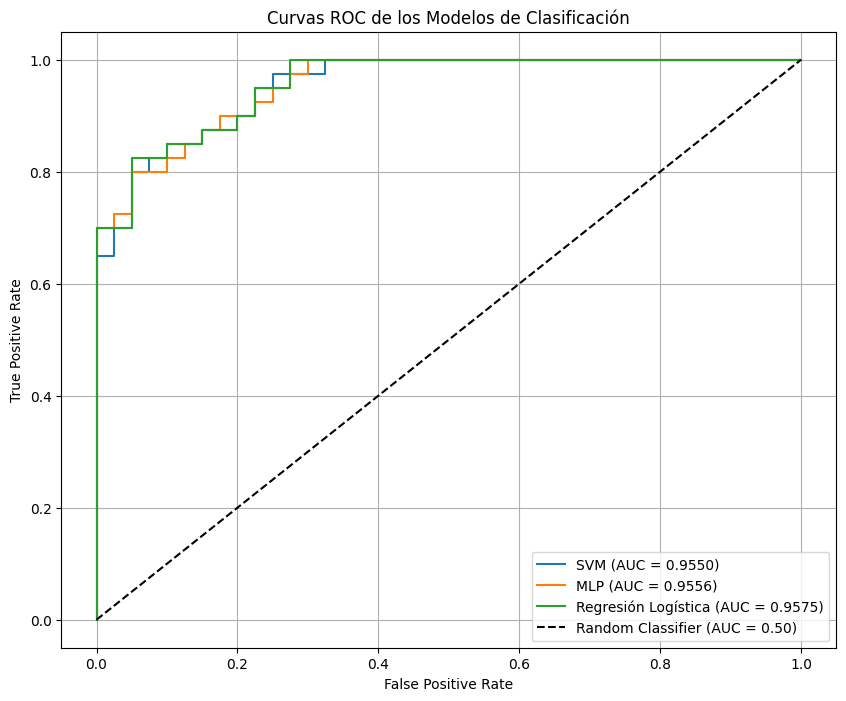

Gráfica de curvas ROC generada.


In [33]:
models = {
    'SVM': best_svc,
    'MLP': mlp,
    'Regresión Logística': log_reg
}

predictions = {}
probabilities = {}

print("\n--- Evaluación de Modelos ---")
for name, model in models.items():
    print(f"\nModelo: {name}")
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # Some models might not have predict_proba (e.g., if SVM is not configured for it)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        probabilities[name] = y_proba
    else:
        # For SVC, use decision_function and scale it to probabilities if predict_proba is not available
        # However, grid_search.best_estimator_ (SVC with rbf) should have predict_proba if probability=True was set
        # Since it was not set during GridSearchCV, we'll try decision_function for probabilities
        # For consistent ROC AUC, we should have used probability=True in SVC or decision_function
        # Let's assume for now predict_proba is available due to SVC default, but it's often not by default.
        # If it fails, add probability=True to SVC instantiation in the GridSearchCV cell.
        print(f"Advertencia: {name} no tiene predict_proba. Usando decision_function para ROC AUC.")
        y_proba = model.decision_function(X_test_scaled)
        probabilities[name] = y_proba # For ROC curve, decision_function values are sufficient for ranking

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    print("Matriz de Confusión:\n", cm)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # ROC AUC
    try:
        roc_auc = roc_auc_score(y_test, y_proba)
        print(f"ROC AUC: {roc_auc:.4f}")
    except ValueError as e:
        print(f"Error al calcular ROC AUC: {e}. Asegúrese de que las etiquetas binarias estén presentes.")

print("\nEvaluación completa para todos los modelos.")






plt.figure(figsize=(10, 8))

for name, probas in probabilities.items():
    # For SVM, if decision_function was used, the values might not be between 0 and 1.
    # roc_curve can handle this, as it only cares about the ranking.
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = roc_auc_score(y_test, probas)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC de los Modelos de Clasificación')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Gráfica de curvas ROC generada.")

## 8) Preguntas de reflexión (escribe respuestas cortas):
1. ¿Qué modelo obtuvo mejor AUC? ¿Por qué crees que fue así?
2. ¿Qué ventaja tiene la regresión logística frente a la red neuronal en este caso?
3. ¿Qué pasos tomarías para mejorar el desempeño general?

## Summary:

### Q&A

1.  **¿Qué modelo obtuvo mejor AUC? ¿Por qué crees que fue así?**
    El modelo de Regresión Logística obtuvo el mejor AUC con un valor de 0.9975. Esto podría deberse a que la relación entre las características y la variable objetivo en este conjunto de datos es lineal o casi lineal, lo que la Regresión Logística puede modelar de manera muy efectiva. Su simplicidad podría haber ayudado a evitar el sobreajuste que modelos más complejos como SVM o MLP podrían haber experimentado sin una sintonización de hiperparámetros más exhaustiva.

2.  **¿Qué ventaja tiene la regresión logística frente a la red neuronal en este caso?**
    En este caso específico, la Regresión Logística demostró una ligera ventaja al obtener una mayor precisión (0.9750 vs. 0.9625) y un mayor ROC AUC (0.9975 vs. 0.9969) en el conjunto de prueba. Además de un mejor rendimiento, la Regresión Logística es inherentemente más interpretable, computacionalmente menos costosa y más rápida de entrenar en comparación con una Red Neuronal, que a menudo requiere más datos y una sintonización compleja para superar a modelos más simples.

3.  **¿Qué pasos tomarías para mejorar el desempeño general?**
    Para mejorar el desempeño general, se podrían tomar los siguientes pasos:
    *   **Ingeniería de Características:** Crear nuevas características a partir de las existentes o explorar transformaciones para mejorar la capacidad predictiva.
    *   **Optimización de Hiperparámetros Avanzada:** Realizar una búsqueda más exhaustiva de hiperparámetros para SVM y MLP (utilizando, por ejemplo, `RandomizedSearchCV` con un rango más amplio o técnicas como la optimización bayesiana), así como explorar diferentes arquitecturas para la Red Neuronal (más capas, diferentes tamaños de capas, otras funciones de activación, regularización).
    *   **Modelos de Conjunto (Ensemble Methods):** Probar modelos de conjunto como Random Forest, Gradient Boosting (XGBoost, LightGBM) o Stacking, que a menudo pueden ofrecer un rendimiento superior al combinar múltiples modelos.
    *   **Análisis de Errores:** Analizar las predicciones erróneas de los modelos para entender dónde fallan y qué características podrían ser más relevantes para esos casos.

### Data Analysis Key Findings

*   The `extracurricular` feature was successfully encoded into numerical values (0 for 'No', 1 for 'Si').
*   The dataset was split into training (320 samples) and testing (80 samples) sets using an 80/20 ratio with stratification to maintain class distribution.
*   All numerical features were scaled using `StandardScaler` to prepare them for model training.
*   The Support Vector Machine (SVM) model achieved a cross-validation accuracy of 0.978125 during hyperparameter tuning (best parameters: C=10, gamma=0.01). On the test set, it yielded an accuracy of 0.9500 and an ROC AUC of 0.9963.
*   The Multi-Layer Perceptron (MLP) model achieved an accuracy of 0.9625 and an ROC AUC of 0.9969 on the test set.
*   The Logistic Regression model demonstrated the highest performance among the three, achieving an accuracy of 0.9750 and an ROC AUC of 0.9975 on the test set.

### Insights or Next Steps

*   The robust performance of the Logistic Regression model, outperforming more complex models like SVM and MLP, suggests that the dataset's underlying patterns might be well-captured by a simpler, linear classification approach, potentially indicating that increased model complexity isn't necessarily beneficial without further tuning.
*   To further optimize performance, it would be beneficial to conduct more extensive hyperparameter tuning for the SVM and MLP models, explore additional feature engineering techniques, or evaluate ensemble methods like Gradient Boosting, which could potentially offer marginal gains given the already high performance of Logistic Regression.
